# Geiger-Mueller probe — 60-second dose measurement

Connects to a remote Geiger probe over a ser2net TCP bridge, prints a full
device status snapshot, then polls the detector for one minute and displays
the dose rate (counts per second, uncalibrated) as a matplotlib figure.

**Prerequisites**: `pip install -e ".[dev]"` from the repo root.

In [5]:
import logging
import time

import matplotlib.pyplot as plt
import numpy as np

from nlab_modbus.core.enums import DeviceType
from nlab_modbus.maps.geiger_map import GEIGER_REGISTER_MAP
from nlab_modbus.services.manager import DeviceManager

logging.basicConfig(
    level=logging.WARNING,
    format="%(asctime)s | %(levelname)-8s | %(name)s | %(message)s",
    force=True,
)
logging.getLogger("pymodbus").setLevel(logging.CRITICAL)

## Configuration

Edit the variables below to match your setup.

In [6]:
HOST          = "192.168.10.134"   # IP address of the ser2net bridge
PORT          = 5002              # TCP port on the bridge
DEVICE_ID     = 2                 # Modbus device address (1-16)

DURATION_S    = 60                # measurement window in seconds
POLL_INTERVAL = 0.5               # seconds between reads (≥ 0.2 recommended)

## Connect

In [7]:
mgr = DeviceManager()
device = mgr.connect_remote(HOST, PORT, DEVICE_ID, DeviceType.GEIGER)

print(f"Connected: {device.connection_info()}  |  type: {device.device_type.name}")

Connected: 192.168.10.134:5002:2  |  type: GEIGER


## Device status snapshot

Reads all holding and input registers once and prints them with engineering units.

In [8]:
def _unit(name: str) -> str:
    spec = GEIGER_REGISTER_MAP.get(name)
    return spec.unit if (spec and spec.unit) else ""


def print_status(dev) -> None:
    holding = dev.get_all_holding_registers()
    inputs  = dev.get_all_input_registers()

    col_w = max(len(k) for k in {**holding, **inputs})

    print(f"{'─' * 55}")
    print(f"  {dev.device_type.name} — {dev.connection_info()}")
    print(f"{'─' * 55}")

    print("\n  [Holding registers — read/write]")
    for name, value in holding.items():
        unit = _unit(name)
        print(f"    {name:<{col_w}}  {value:>10.4g}  {unit}")

    print("\n  [Input registers — read-only]")
    for name, value in inputs.items():
        unit = _unit(name)
        print(f"    {name:<{col_w}}  {value:>10.4g}  {unit}")

    print(f"{'─' * 55}\n")


print_status(device)

───────────────────────────────────────────────────────
  GEIGER — 192.168.10.134:5002:2
───────────────────────────────────────────────────────

  [Holding registers — read/write]
    rs485_mb_addr                2  
    rs485_baud                9600  
    pwm_enable                   1  
    pwm_set_voltage            550  V
    dac_vout_mv                200  mV
    dac_vout_mv_2              200  mV
    pwm_freq_khz               100  kHz
    pwm_max_duty                40  %
    pwm_outvolt_comp             4  %
    dac_vout_mv_3              200  mV
    scale_coeff_p1_a2            0  
    scale_exp_p1_a2              0  
    scale_coeff_p1_a1            1  
    scale_exp_p1_a1              0  
    scale_coeff_p1_a0            0  
    scale_exp_p1_a0              0  
    scale_coeff_th               0  
    scale_exp_th                 0  
    scale_coeff_p2_a2            0  
    scale_exp_p2_a2              0  
    scale_coeff_p2_a1            1  
    scale_exp_p2_a1           

## Measurement

Polls `pulses_per_sec` (counts per second, uncalibrated dose rate) and
`dose_level_msvh` (calibrated dose rate) for `DURATION_S` seconds at
`POLL_INTERVAL` intervals.  Progress is printed inline.

In [9]:
times_s        = []   # elapsed time in seconds
cps_series     = []   # raw counts per second (dose rate a.u.)
dose_rate_msvh = []   # calibrated dose rate in mSv/h (may be 0 if uncalibrated)
hv_series      = []   # HV output voltage for reference

t0        = time.perf_counter()
next_tick = t0 + POLL_INTERVAL

print(f"Measuring for {DURATION_S} s  (Ctrl-C to stop early)\n")
print(f"  {'Time':>6}   {'CPS':>6}   {'Dose rate':>10}   {'HV':>6}")
print(f"  {'[s]':>6}   {'[a.u.]':>6}   {'[mSv/h]':>10}   {'[V]':>6}")
print(f"  {'─'*6}   {'─'*6}   {'─'*10}   {'─'*6}")

try:
    while True:
        elapsed = time.perf_counter() - t0
        if elapsed >= DURATION_S:
            break

        # Single bus transaction: read snapshot registers 3-19 in one FC04 call
        snap = device.read_snapshot()

        cps      = int(snap.get("pulses_per_sec", 0))
        dose_r   = snap.get("dose_level_msvh", 0.0)
        hv       = snap.get("hv_voltage", 0.0)

        times_s.append(elapsed)
        cps_series.append(cps)
        dose_rate_msvh.append(dose_r)
        hv_series.append(hv)

        print(f"  {elapsed:6.1f}   {cps:6d}   {dose_r:10.4f}   {hv:6.1f}", end="\r")

        # Drift-compensating sleep: target absolute ticks, not relative delays
        sleep_dur = next_tick - time.perf_counter()
        if sleep_dur > 0:
            time.sleep(sleep_dur)
        next_tick += POLL_INTERVAL

except KeyboardInterrupt:
    print("\nInterrupted early.")

times_s        = np.array(times_s)
cps_series     = np.array(cps_series)
dose_rate_msvh = np.array(dose_rate_msvh)
hv_series      = np.array(hv_series)

# Cumulative dose: integrate CPS over time (trapezoidal rule)
cum_counts = np.concatenate(([0.0], np.cumsum(
    0.5 * (cps_series[:-1] + cps_series[1:]) * np.diff(times_s)
)))

print(f"\n\nDone.  {len(times_s)} samples over {times_s[-1]:.1f} s")
print(f"  Mean CPS        : {cps_series.mean():.1f}")
print(f"  Max CPS         : {cps_series.max()}")
print(f"  Accumulated dose: {cum_counts[-1]:.0f} counts  (a.u.)")

Measuring for 60 s  (Ctrl-C to stop early)

    Time      CPS    Dose rate       HV
     [s]   [a.u.]      [mSv/h]      [V]
  ──────   ──────   ──────────   ──────
    59.5       26      26.0000    550.0

Done.  120 samples over 59.5 s
  Mean CPS        : 35.3
  Max CPS         : 56
  Accumulated dose: 2102 counts  (a.u.)


## Plot

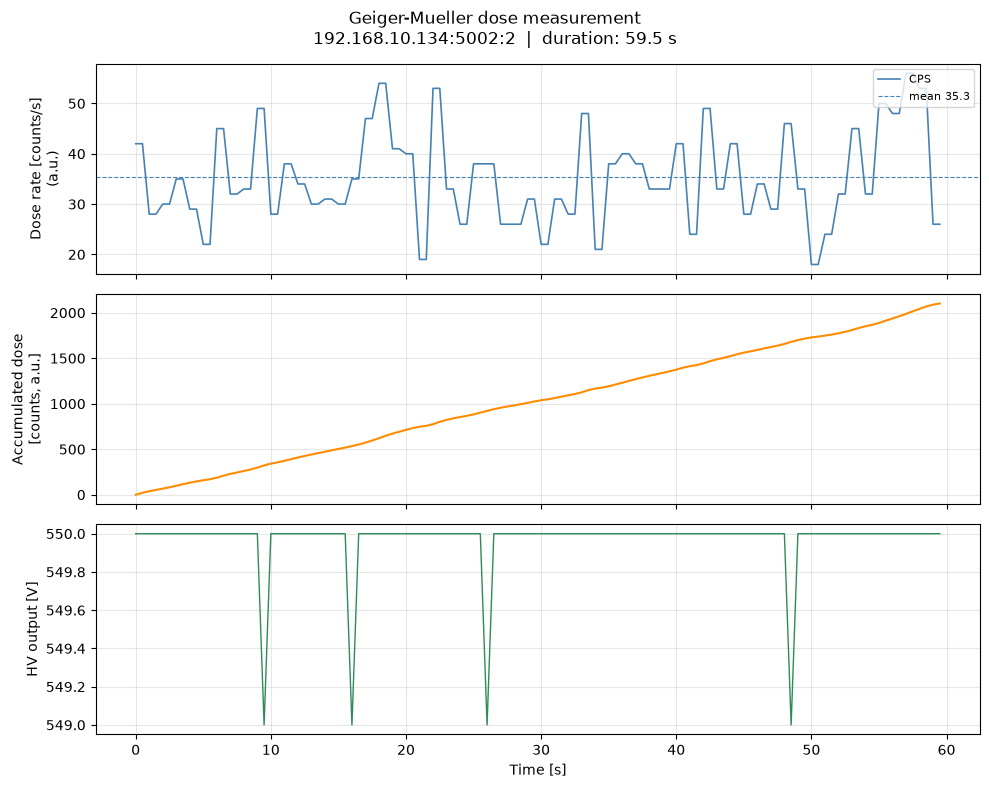

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig.suptitle(
    f"Geiger-Mueller dose measurement\n"
    f"{device.connection_info()}  |  duration: {times_s[-1]:.1f} s",
    fontsize=12,
)

# --- top panel: dose rate (raw CPS) ---
ax0 = axes[0]
ax0.plot(times_s, cps_series, color="steelblue", linewidth=1.2, label="CPS")
ax0.axhline(cps_series.mean(), color="steelblue", linestyle="--", linewidth=0.8,
            label=f"mean {cps_series.mean():.1f}")
ax0.set_ylabel("Dose rate [counts/s]\n(a.u.)")
ax0.legend(loc="upper right", fontsize=8)
ax0.grid(True, alpha=0.3)

# --- middle panel: cumulative dose ---
ax1 = axes[1]
ax1.plot(times_s, cum_counts, color="darkorange", linewidth=1.5)
ax1.set_ylabel("Accumulated dose\n[counts, a.u.]")
ax1.grid(True, alpha=0.3)

# --- bottom panel: HV output (diagnostic) ---
ax2 = axes[2]
ax2.plot(times_s, hv_series, color="seagreen", linewidth=1.0)
ax2.set_ylabel("HV output [V]")
ax2.set_xlabel("Time [s]")
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Disconnect

In [11]:
mgr.close_all()
print("Connection closed.")

Connection closed.
